# Series multivariadas y datos tipo panel

## Tópicos Selectos de Matemáticas Aplicadas II

En el notebook anterior construimos un panel horario de concentraciones de ozono correspondiente a $14$ estaciones de monitoreo.

Ahora utilizaremos ese conjunto de datos para estudiar tres estructuras fundamentales en el análisis de datos temporales:

$$
Y_t,
$$

$$
\mathbf{X}_t=
(X_{1,t},X_{2,t},\ldots,X_{p,t}),
$$

y

$$
Y_{i,t}.
$$

Aunque estas expresiones están relacionadas, representan formas diferentes de organizar e interpretar la información.



## 1. Serie temporal univariada

Una serie temporal univariada contiene una sola variable observada a través del tiempo:

$$
Y_t,
\qquad
t=1,\ldots,T.
$$

Por ejemplo, si seleccionamos únicamente la estación `AJM`, podemos representar su concentración horaria de ozono como

$$
Y_t=
\text{O}_3\text{ registrado en AJM en el instante }t.
$$

En este caso existe una sola observación para cada instante temporal.



## 2. Serie temporal multivariada

Si observamos simultáneamente varias estaciones, en cada instante temporal tenemos un vector:

$$
\mathbf{X}_t
=
\left(
X_{1,t},
X_{2,t},
\ldots,
X_{p,t}
\right).
$$

En nuestro caso, $p=14,$ por lo que cada hora puede representarse mediante un vector con las concentraciones de ozono registradas en las $14$ estaciones seleccionadas.

La estructura completa puede visualizarse como una matriz

$$
\mathbf{X}
=
\begin{pmatrix}
X_{1,1} & X_{2,1} & \cdots & X_{p,1}\\
X_{1,2} & X_{2,2} & \cdots & X_{p,2}\\
\vdots & \vdots & & \vdots\\
X_{1,T} & X_{2,T} & \cdots & X_{p,T}
\end{pmatrix}.
$$

Las filas representan instantes temporales y las columnas representan variables o estaciones.



## 3. Datos tipo panel

Otra forma de representar la misma información consiste en considerar explícitamente dos índices:

$$
Y_{i,t},
$$

donde

- $i$ identifica una unidad;
- $t$ identifica el tiempo.

En nuestro ejemplo,

$$
i=\text{estación de monitoreo}
$$

y

$$
t=\text{hora}.
$$

Por tanto,

$$
Y_{i,t}
=
\text{concentración de O}_3
\text{ en la estación }i
\text{ durante la hora }t.
$$

Esta representación será especialmente útil cuando incorporemos otras variables asociadas con cada estación o con cada instante temporal.


## Objetivos


- distinguir entre series univariadas, multivariadas y datos tipo panel;
- transformar datos entre formato largo y formato ancho;
- identificar correctamente la unidad temporal y la unidad espacial;
- utilizar índices jerárquicos (`MultiIndex`);
- verificar si un panel está balanceado;
- detectar combinaciones estación--tiempo faltantes;
- estudiar relaciones entre las series de distintas estaciones;
- integrar posteriormente múltiples fuentes de información.

El flujo principal será

$$
\boxed{
Y_t
\rightarrow
\mathbf{X}_t
\rightarrow
Y_{i,t}
\rightarrow
\text{formato largo/ancho}
\rightarrow
\text{panel}
}
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/panel_o3_2026.csv" 

panel = pd.read_csv(ruta,parse_dates=["timestamp", "fecha"])


print("Dimensiones del panel:")
print(panel.shape)

print("\nColumnas:")
print(panel.columns.tolist())

print("\nPrimeras observaciones:")
display(panel.head())

print("\nTipos de datos:")
display(panel.dtypes.to_frame("tipo"))

print("\nNúmero de estaciones:")
print(panel["estacion"].nunique())

print("\nNúmero de instantes temporales:")
print(panel["timestamp"].nunique())

Dimensiones del panel:
(19824, 7)

Columnas:
['timestamp', 'fecha', 'hora', 'estacion', 'o3', 'imputado', 'baja_disponibilidad']

Primeras observaciones:


,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad
0,2026-01-01 01:00:00,2026-01-01,1,AJM,19.0,False,False
1,2026-01-01 02:00:00,2026-01-01,2,AJM,23.0,False,False
2,2026-01-01 03:00:00,2026-01-01,3,AJM,30.0,False,False
3,2026-01-01 04:00:00,2026-01-01,4,AJM,34.0,False,False
4,2026-01-01 05:00:00,2026-01-01,5,AJM,36.0,False,False



Tipos de datos:


,tipo
timestamp,datetime64[ns]
fecha,datetime64[ns]
hora,int64
estacion,object
o3,float64
imputado,bool
baja_disponibilidad,bool



Número de estaciones:
14

Número de instantes temporales:
1416


## De un panel a una serie univariada y una serie multivariada

El archivo que acabamos de cargar se encuentra en **formato largo**.

Cada fila representa una combinación

$$
(i,t),
$$

donde:

- $i$ identifica una estación;
- $t$ identifica un instante temporal;
- $Y_{i,t}$ es la concentración de ozono observada en esa combinación.

Por ejemplo,

$$
Y_{\text{AJM},t}
$$

representa la concentración de O$_3$ en la estación `AJM` durante el instante $t$.



### Serie temporal univariada

Si seleccionamos una sola estación, por ejemplo `AJM`, desaparece el índice espacial y obtenemos una serie temporal univariada:

$$
Y_t.
$$

En este caso tendremos $1416$ observaciones ordenadas en el tiempo.



### Serie temporal multivariada

Si consideramos simultáneamente las $14$ estaciones, cada instante temporal queda asociado con un vector

$$
\mathbf{X}_t=\left(X_{1,t},X_{2,t},\ldots,X_{14,t}\right).
$$

Por ejemplo, para una hora determinada podemos tener

$$
\mathbf{X}_t=(X_{\text{AJM},t},X_{\text{ATI},t},\ldots,X_{\text{VIF},t}).
$$

Para representar esta estructura de manera natural utilizaremos **formato ancho**, donde:

- cada fila representa un instante temporal;
- cada columna representa una estación.

Por tanto, el mismo conjunto de información puede interpretarse de tres formas:

$$
\boxed{Y_{i,t}\longleftrightarrow Y_t \longleftrightarrow \mathbf{X}_t
}
$$

dependiendo de la pregunta que deseamos responder.

In [3]:
# Serie temporal univariada: estación AJM

serie_ajm = (
    panel.loc[panel["estacion"] == "AJM",["timestamp", "o3"]]
    .set_index("timestamp").sort_index()
)

print("Serie univariada AJM:")
print("Dimensiones:", serie_ajm.shape)

serie_ajm.head()

Serie univariada AJM:
Dimensiones: (1416, 1)


,o3
timestamp,
2026-01-01 01:00:00,19.0
2026-01-01 02:00:00,23.0
2026-01-01 03:00:00,30.0
2026-01-01 04:00:00,34.0
2026-01-01 05:00:00,36.0


In [4]:
# Serie temporal multivariada: formato ancho

serie_multivariada = (panel
    .pivot(index="timestamp", columns="estacion", values="o3").sort_index()
)

print("\nSerie multivariada:")
print("Dimensiones:", serie_multivariada.shape)

serie_multivariada.head()


Serie multivariada:
Dimensiones: (1416, 14)


estacion,AJM,ATI,FAC,GAM,HGM,INN,LLA,MER,MGH,PED,TLA,UAX,UIZ,VIF
timestamp,,,,,,,,,,,,,,
2026-01-01 01:00:00,19.0,18.0,19.0,2.0,12.0,9.0,6.0,7.0,18.0,4.0,5.0,23.0,14.0,4.0
2026-01-01 02:00:00,23.0,11.0,12.0,6.0,10.0,11.0,1.0,3.0,17.0,12.0,6.0,11.0,5.0,7.0
2026-01-01 03:00:00,30.0,13.0,9.0,4.0,4.0,12.0,1.0,3.0,8.0,15.0,7.0,1.0,2.0,9.0
2026-01-01 04:00:00,34.0,8.0,9.0,2.0,3.0,17.0,1.0,3.0,3.0,18.0,5.0,2.0,3.0,9.0
2026-01-01 05:00:00,36.0,4.0,7.0,3.0,3.0,22.0,0.0,4.0,2.0,20.0,8.0,2.0,3.0,8.0


In [5]:
# Un vector X_t en un instante específico

t = serie_multivariada.index[200]

X_t = serie_multivariada.loc[t]

print(f"\nVector X_t para t = {t}:")
X_t.to_frame("O3")


Vector X_t para t = 2026-01-09 09:00:00:


,O3
estacion,
AJM,26.0
ATI,2.0
FAC,4.0
GAM,8.0
HGM,3.0
INN,17.0
LLA,1.0
MER,4.0
MGH,3.0


## Formato largo y formato ancho

Los mismos datos pueden organizarse de diferentes maneras dependiendo del tipo de análisis que queramos realizar.

### Formato largo

En el formato largo, cada fila representa una combinación

$$
(i,t),
$$

donde $i$ corresponde a la estación y $t$ al instante temporal.

La estructura general es

$$
\begin{array}{c|c|c}
t & i & Y_{i,t}\\
\hline
t_1 & 1 & Y_{1,t_1}\\
t_1 & 2 & Y_{2,t_1}\\
t_1 & 3 & Y_{3,t_1}\\
t_2 & 1 & Y_{1,t_2}\\
\vdots & \vdots & \vdots
\end{array}
$$



Este formato es especialmente útil para:

* agrupar por estación;
* agregar covariables;
* construir modelos con estructura estación--tiempo;
* realizar operaciones con `groupby()`;
* integrar múltiples fuentes de datos.



### Formato ancho

En el formato ancho, cada fila representa un instante temporal y cada estación aparece como una columna:

$$
\begin{array}{c|cccc}
t & X_{1,t} & X_{2,t} & \cdots & X_{p,t}\\
\hline
t_1 & X_{1,t_1} & X_{2,t_1} & \cdots & X_{p,t_1}\\
t_2 & X_{1,t_2} & X_{2,t_2} & \cdots & X_{p,t_2}\\
\vdots & \vdots & \vdots & & \vdots
\end{array}
$$

Este formato resulta conveniente para:

* representar una serie temporal multivariada;
* calcular correlaciones entre estaciones;
* aplicar métodos multivariados;
* realizar operaciones matriciales.

En `pandas`, podemos transformar

$$
\text{largo}\longrightarrow\text{ancho}
$$

mediante `pivot()` y regresar

$$
\text{ancho}\longrightarrow\text{largo}
$$

mediante `melt()`.

El formato modifica la **representación**, pero no la información contenida en los datos.

In [6]:
# Formato largo 

panel_largo = panel[["timestamp", "estacion", "o3"]].copy()

print("Formato largo:")
print("Dimensiones:", panel_largo.shape)

panel_largo

Formato largo:
Dimensiones: (19824, 3)


,timestamp,estacion,o3
0,2026-01-01 01:00:00,AJM,19.0
1,2026-01-01 02:00:00,AJM,23.0
2,2026-01-01 03:00:00,AJM,30.0
3,2026-01-01 04:00:00,AJM,34.0
4,2026-01-01 05:00:00,AJM,36.0
...,...,...,...
19819,2026-02-28 20:00:00,VIF,28.0
19820,2026-02-28 21:00:00,VIF,24.0
19821,2026-02-28 22:00:00,VIF,18.0
19822,2026-02-28 23:00:00,VIF,3.0


In [7]:
# De formato largo a formato ancho

panel_ancho = panel_largo.pivot(index="timestamp", columns="estacion", values="o3").sort_index()

print("\nFormato ancho:")
print("Dimensiones:", panel_ancho.shape)
panel_ancho


Formato ancho:
Dimensiones: (1416, 14)


estacion,AJM,ATI,FAC,GAM,HGM,INN,LLA,MER,MGH,PED,TLA,UAX,UIZ,VIF
timestamp,,,,,,,,,,,,,,
2026-01-01 01:00:00,19.0,18.0,19.0,2.0,12.0,9.0,6.0,7.0,18.0,4.0,5.0,23.0,14.0,4.0
2026-01-01 02:00:00,23.0,11.0,12.0,6.0,10.0,11.0,1.0,3.0,17.0,12.0,6.0,11.0,5.0,7.0
2026-01-01 03:00:00,30.0,13.0,9.0,4.0,4.0,12.0,1.0,3.0,8.0,15.0,7.0,1.0,2.0,9.0
2026-01-01 04:00:00,34.0,8.0,9.0,2.0,3.0,17.0,1.0,3.0,3.0,18.0,5.0,2.0,3.0,9.0
2026-01-01 05:00:00,36.0,4.0,7.0,3.0,3.0,22.0,0.0,4.0,2.0,20.0,8.0,2.0,3.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-28 20:00:00,42.0,29.0,36.0,31.0,38.0,33.0,39.0,31.0,32.0,39.0,35.0,42.0,24.0,28.0
2026-02-28 21:00:00,36.0,26.0,27.0,28.0,34.0,25.0,35.0,28.0,30.0,34.0,28.0,28.0,18.0,24.0
2026-02-28 22:00:00,23.0,21.0,10.0,20.0,29.0,20.0,31.0,21.0,21.0,27.0,17.0,19.0,12.0,18.0


* **`.melt(id_vars="timestamp", var_name="estacion", value_name="o3")`**:
* Mantiene la columna `timestamp` fija (`id_vars`).
* Convierte todas las demás columnas (que representan las estaciones) en filas bajo una nueva columna llamada `estacion` (`var_name`).
* Coloca los valores correspondientes de cada celda en una columna llamada `o3` (`value_name`), refiriéndose probablemente a niveles de ozono.


* **`.sort_values(["estacion", "timestamp"])`**: Ordena el DataFrame resultante agrupando primero por estación y luego cronológicamente por el sello de tiempo.
* **`.reset_index(drop=True)`**: Restablece el índice numérico del DataFrame para que quede limpio y secuencial (0, 1, 2...).


In [8]:
# De formato ancho a formato largo

panel_largo_recuperado = (
    panel_ancho.reset_index()
    .melt(id_vars="timestamp", var_name="estacion", value_name="o3")
    .sort_values(["estacion", "timestamp"])
    .reset_index(drop=True)
)


print("\nFormato largo recuperado:")
print("Dimensiones:", panel_largo_recuperado.shape)

panel_largo_recuperado


Formato largo recuperado:
Dimensiones: (19824, 3)


,timestamp,estacion,o3
0,2026-01-01 01:00:00,AJM,19.0
1,2026-01-01 02:00:00,AJM,23.0
2,2026-01-01 03:00:00,AJM,30.0
3,2026-01-01 04:00:00,AJM,34.0
4,2026-01-01 05:00:00,AJM,36.0
...,...,...,...
19819,2026-02-28 20:00:00,VIF,28.0
19820,2026-02-28 21:00:00,VIF,24.0
19821,2026-02-28 22:00:00,VIF,18.0
19822,2026-02-28 23:00:00,VIF,3.0


## Panel balanceado y panel no balanceado

Un panel se denomina **balanceado** cuando todas las unidades están observadas en todos los instantes temporales.

Si tenemos $N$ unidades y $T$ instantes, un panel balanceado contiene exactamente

$$
N\times T
$$

combinaciones distintas.

En nuestro caso:

$$
N=14,
\qquad
T=1416,
$$

por lo que esperamos $14\times1416=19\,824$ combinaciones estación--tiempo.

Formalmente, si

$$
\mathcal{I}=\{1,\ldots,N\}
$$

representa las estaciones y

$$
\mathcal{T}=\{t_1,\ldots,t_T\}
$$

los instantes temporales, un panel balanceado contiene todo el producto cartesiano

$$
\mathcal{I}\times\mathcal{T}.
$$

Un panel es **no balanceado** cuando alguna combinación $(i,t)$ no existe en la estructura de los datos.

Es importante distinguir entre:

$$
\boxed{\text{combinación ausente}}
$$

y

$$
\boxed{\text{combinación existente con valor faltante}}.
$$

En el primer caso, la fila $(i,t)$ no existe en el panel. En el segundo, la combinación sí está presente pero alguna de sus variables contiene `NaN`.

Nuestro panel final fue construido para contener todas las combinaciones estación--tiempo, por lo que esperamos que sea estructuralmente balanceado.


In [9]:
panel_indexado = panel.set_index(["estacion", "timestamp"]).sort_index()
panel_indexado

fecha  hora    o3  imputado  \
estacion timestamp                                              
AJM      2026-01-01 01:00:00 2026-01-01     1  19.0     False   
         2026-01-01 02:00:00 2026-01-01     2  23.0     False   
         2026-01-01 03:00:00 2026-01-01     3  30.0     False   
         2026-01-01 04:00:00 2026-01-01     4  34.0     False   
         2026-01-01 05:00:00 2026-01-01     5  36.0     False   
...                                 ...   ...   ...       ...   
VIF      2026-02-28 20:00:00 2026-02-28    20  28.0     False   
         2026-02-28 21:00:00 2026-02-28    21  24.0     False   
         2026-02-28 22:00:00 2026-02-28    22  18.0     False   
         2026-02-28 23:00:00 2026-02-28    23   3.0     False   
         2026-03-01 00:00:00 2026-02-28    24   9.0     False   

                              baja_disponibilidad  
estacion timestamp                                 
AJM      2026-01-01 01:00:00                False  
         2026-01-01 02:00:00                False  
         2026-01-01 03:00:00                False  
         2026-01-01 04:00:00                False  
         2026-01-01 05:00:00                False  
...                                           ...  
VIF      2026-02-28 20:00:00                False  
         2026-02-28 21:00:00                False  
         2026-02-28 22:00:00                False  
         2026-02-28 23:00:00                False  
         2026-03-01 00:00:00                False  

[19824 rows x 5 columns]

In [10]:
# Unidades y tiempos presentes en el panel
estaciones_panel = panel_indexado.index.get_level_values("estacion").unique()

tiempos_panel = panel_indexado.index.get_level_values("timestamp").unique()

N = len(estaciones_panel)
T = len(tiempos_panel)

print("Número de estaciones N:")
print(N)

print("\nNúmero de instantes T:")
print(T)

Número de estaciones N:
14

Número de instantes T:
1416


In [11]:
# Producto cartesiano estación × tiempo

indice_completo = pd.MultiIndex.from_product(
    [
        estaciones_panel,
        tiempos_panel
    ],
    names=["estacion", "timestamp"]
)

print("\nNúmero esperado de combinaciones:")
print(len(indice_completo))

print("\nNúmero observado de combinaciones:")
print(len(panel_indexado))


Número esperado de combinaciones:
19824

Número observado de combinaciones:
19824


In [12]:
# Combinaciones faltantes en el panel real

combinaciones_faltantes = indice_completo.difference(panel_indexado.index)

print("\nCombinaciones estación-tiempo faltantes:")
print(len(combinaciones_faltantes))


Combinaciones estación-tiempo faltantes:
0


## Relación entre las estaciones: matriz de correlaciones

En una serie temporal multivariada no solamente interesa estudiar cada variable por separado.

También queremos conocer qué tan relacionadas están las diferentes componentes del vector

$$
\mathbf{X}_t
=
\left(
X_{1,t},
X_{2,t},
\ldots,
X_{p,t}
\right).
$$

En nuestro caso, cada componente corresponde a la concentración de ozono registrada por una estación diferente.





### Matriz de correlaciones

Para $p$ estaciones podemos construir una matriz

$$
\mathbf{R}=
\begin{pmatrix}
1 & r_{12} & \cdots & r_{1p}\\
r_{21} & 1 & \cdots & r_{2p}\\
\vdots & \vdots & \ddots & \vdots\\
r_{p1} & r_{p2} & \cdots & 1
\end{pmatrix}.
$$

Esta matriz permite identificar grupos de estaciones con comportamientos temporales similares.

Debe recordarse que una correlación elevada no implica que las estaciones tengan exactamente las mismas concentraciones ni establece una relación causal. Únicamente mide qué tan parecido es su comportamiento lineal durante el periodo analizado.

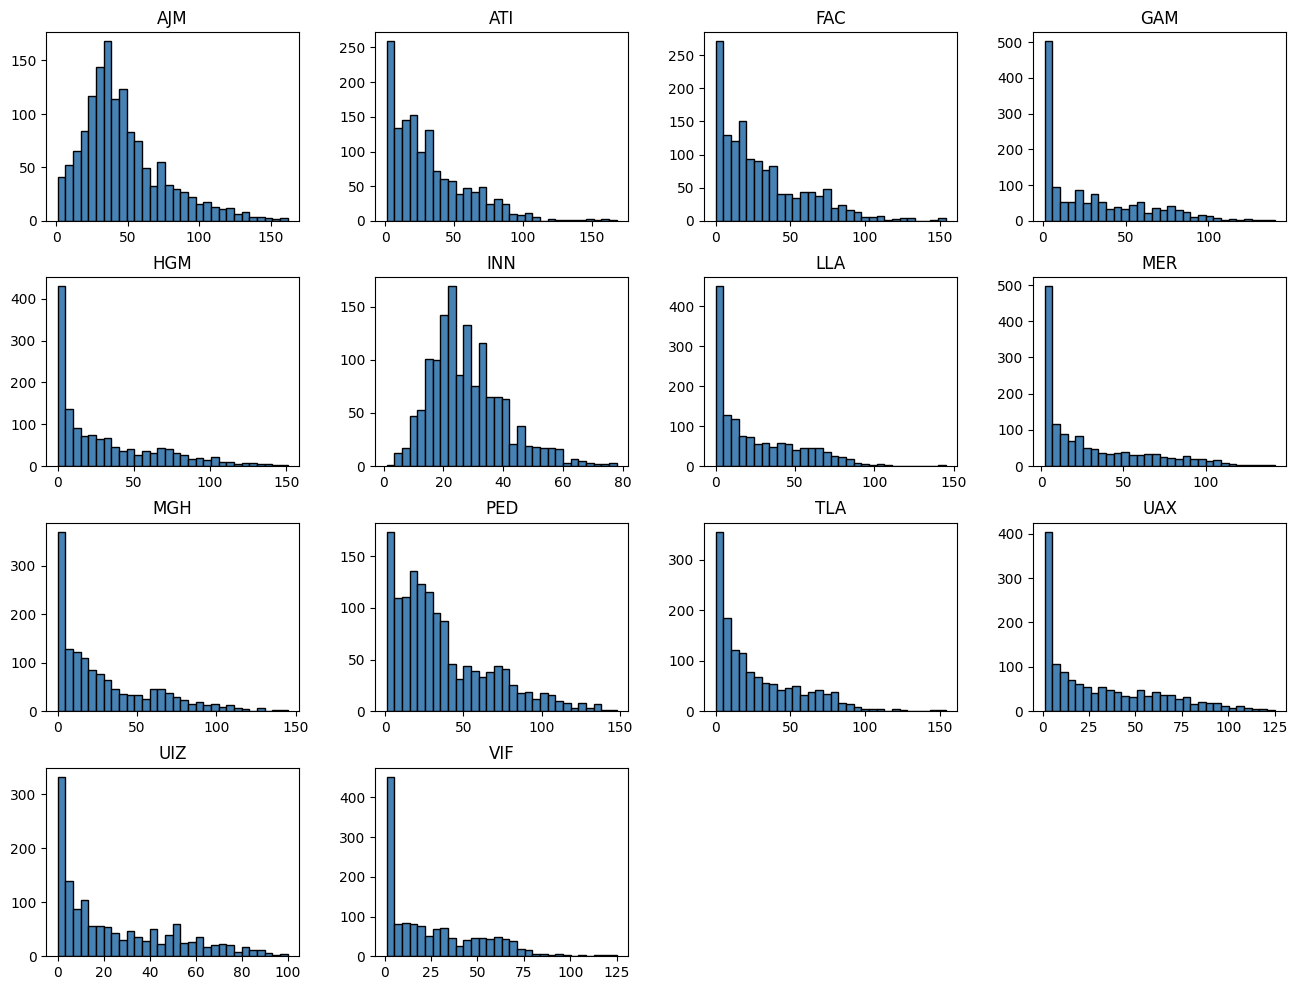

In [13]:
df_vars = serie_multivariada.select_dtypes(include='number')

df_vars.hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='black', grid=False)

plt.show()

In [14]:
# Matriz de correlaciones entre estaciones

correlaciones = serie_multivariada.corr('spearman')

print("Matriz de correlaciones:")
correlaciones.round(2)

Matriz de correlaciones:


estacion,AJM,ATI,FAC,GAM,HGM,INN,LLA,MER,MGH,PED,TLA,UAX,UIZ,VIF
estacion,,,,,,,,,,,,,,
AJM,1.00,0.76,0.72,0.62,0.67,0.79,0.63,0.63,0.67,0.85,0.68,0.69,0.68,0.58
ATI,0.76,1.00,0.92,0.81,0.87,0.63,0.84,0.82,0.89,0.89,0.89,0.84,0.84,0.81
FAC,0.72,0.92,1.00,0.83,0.88,0.63,0.84,0.83,0.91,0.88,0.90,0.84,0.83,0.83
GAM,0.62,0.81,0.83,1.00,0.92,0.58,0.91,0.92,0.90,0.78,0.89,0.93,0.92,0.92
HGM,0.67,0.87,0.88,0.92,1.00,0.60,0.93,0.94,0.94,0.83,0.91,0.93,0.92,0.91
INN,0.79,0.63,0.63,0.58,0.60,1.00,0.58,0.57,0.59,0.69,0.59,0.63,0.62,0.55
LLA,0.63,0.84,0.84,0.91,0.93,0.58,1.00,0.91,0.90,0.80,0.88,0.91,0.89,0.93
MER,0.63,0.82,0.83,0.92,0.94,0.57,0.91,1.00,0.89,0.79,0.89,0.91,0.90,0.90
MGH,0.67,0.89,0.91,0.90,0.94,0.59,0.90,0.89,1.00,0.84,0.90,0.90,0.89,0.90


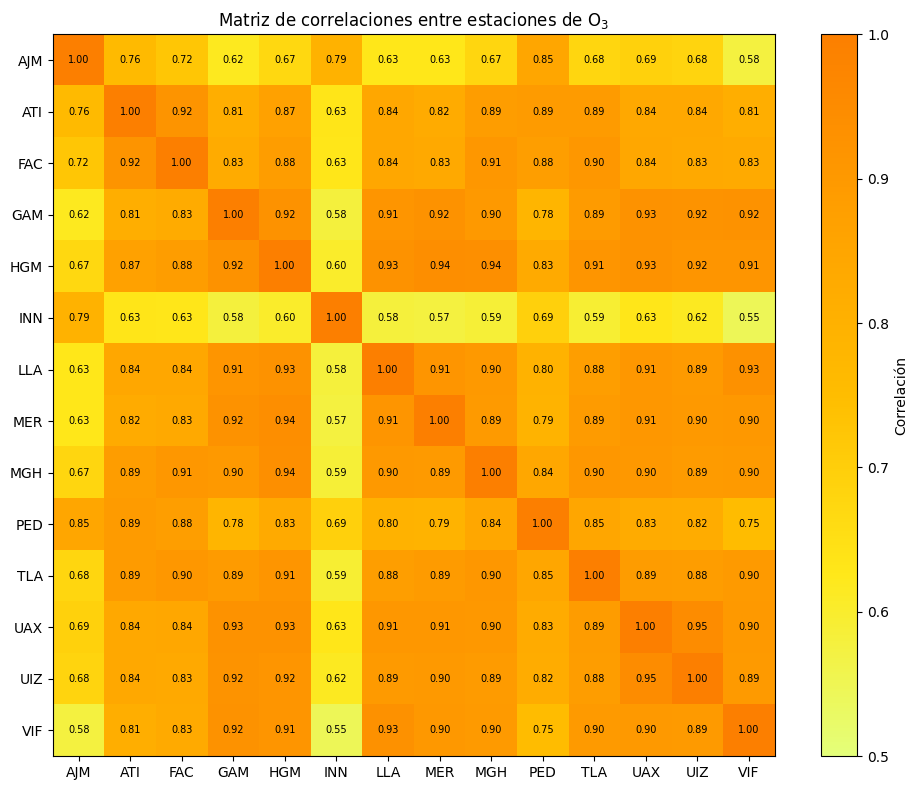

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

imagen = ax.imshow(
    correlaciones,
    vmin=0.5,
    vmax=1,
    cmap='Wistia'
)

ax.set_xticks(np.arange(len(correlaciones.columns)))
ax.set_yticks(np.arange(len(correlaciones.index)))
ax.set_xticklabels(correlaciones.columns)
ax.set_yticklabels(correlaciones.index)
ax.set_title("Matriz de correlaciones entre estaciones de O$_3$")


for i in range(len(correlaciones.index)):
    for j in range(len(correlaciones.columns)):

        ax.text(
            j,
            i,
            f"{correlaciones.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )


fig.colorbar(imagen, ax=ax, label="Correlación")

plt.tight_layout()
plt.show()

## Estaciones con mayor y menor asociación

La matriz de correlaciones contiene información repetida porque

$$
r_{ij}=r_{ji},
$$

y además la diagonal siempre satisface

$$
r_{ii}=1.
$$

Por esta razón, para comparar pares de estaciones basta con conservar uno de los triángulos de la matriz y excluir la diagonal.

Con $p=14$ estaciones existen

$$
\binom{14}{2}
=
\frac{14(13)}{2}
=
91
$$

pares diferentes.

Ordenaremos estos pares según su correlación para identificar:

- estaciones con comportamientos temporales muy similares;
- estaciones con comportamientos relativamente diferentes.

En nuestros datos ya se observa que muchas correlaciones son superiores a $0.90$, lo que sugiere una fuerte estructura común en la evolución temporal del O$_3$.

Sin embargo, una correlación menor no significa que una estación sea incorrecta o de mala calidad. Puede indicar que su dinámica temporal difiere de la observada en otras estaciones.

In [16]:
# Correlaciones únicas entre pares de estaciones

pares_correlacion = []

estaciones = correlaciones.columns

for i in range(len(estaciones)):
    for j in range(i + 1, len(estaciones)):

        pares_correlacion.append({
            "estacion_1": estaciones[i],
            "estacion_2": estaciones[j],
            "correlacion": correlaciones.iloc[i, j]
        })

pares_correlacion = pd.DataFrame(pares_correlacion)

# Pares con mayor correlación
mayores = (
    pares_correlacion
    .sort_values("correlacion",ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print("10 pares con mayor correlación:")
mayores.round(3)

10 pares con mayor correlación:


,estacion_1,estacion_2,correlacion
0,UAX,UIZ,0.946
1,HGM,MER,0.941
2,HGM,MGH,0.936
3,LLA,VIF,0.928
4,HGM,LLA,0.927
5,GAM,UAX,0.925
6,HGM,UAX,0.925
7,GAM,HGM,0.925
8,GAM,MER,0.924
9,GAM,VIF,0.924


In [17]:
# Pares con menor correlación
menores = (
    pares_correlacion
    .sort_values("correlacion")
    .head(10)
    .reset_index(drop=True)
)

print("\n10 pares con menor correlación:")
menores.round(3)


10 pares con menor correlación:


,estacion_1,estacion_2,correlacion
0,INN,VIF,0.547
1,INN,MER,0.574
2,AJM,VIF,0.576
3,GAM,INN,0.579
4,INN,LLA,0.581
5,INN,MGH,0.587
6,INN,TLA,0.592
7,HGM,INN,0.603
8,INN,UIZ,0.616
9,AJM,GAM,0.619


In [18]:
print("\nResumen de las correlaciones entre pares:")

display(
    pares_correlacion["correlacion"]
    .describe()
    .to_frame("correlacion")
    .round(3)
)


Resumen de las correlaciones entre pares:


,correlacion
count,91.000
mean,0.816
std,0.116
min,0.547
25%,0.757
50%,0.849
75%,0.903
max,0.946


Aunque las 14 estaciones forman una serie multivariada fuertemente relacionada, no todas aportan exactamente la misma información temporal.

## Comparación de pares con alta y baja correlación

La matriz de correlaciones resume la asociación entre estaciones mediante un solo número. Sin embargo, es útil observar directamente los datos para comprender qué significa una correlación alta o relativamente baja.


Si dos estaciones presentan una correlación cercana a $1$, esperamos que concentraciones altas en una estación estén generalmente acompañadas por concentraciones altas en la otra.

En cambio, una correlación menor indica una relación lineal menos estrecha y una mayor dispersión entre ambas mediciones.

Para visualizar esta relación utilizaremos diagramas de dispersión:

$$
X_t=\text{O}_3\text{ en una estación},
$$

$$
Y_t=\text{O}_3\text{ en otra estación}.
$$

Cada punto representa entonces las concentraciones registradas simultáneamente en ambas estaciones durante una misma hora.

Es importante recordar que

$$
\boxed{\text{correlación}\neq\text{causalidad}}.
$$

Una correlación elevada únicamente indica que dos series presentan un comportamiento lineal similar durante el periodo analizado.

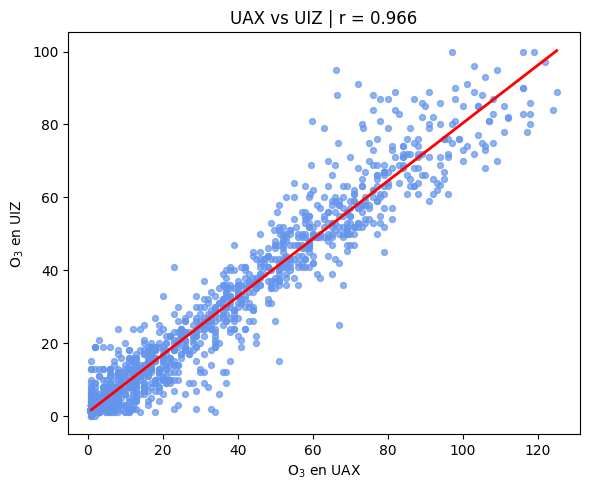

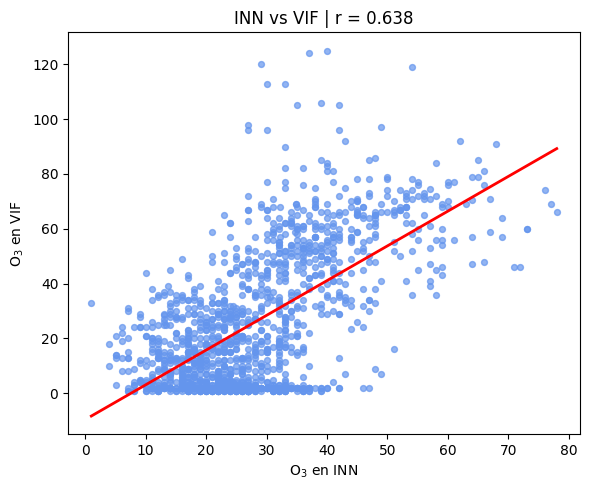

In [19]:
pares = [
    ("UAX", "UIZ"),
    ("INN", "VIF")
]


for estacion_1, estacion_2 in pares:

    x = serie_multivariada[estacion_1]
    y = serie_multivariada[estacion_2]

    r = x.corr(y)

    # Ajuste lineal
    pendiente, intercepto = np.polyfit(x, y, 1)

    x_linea = np.linspace(x.min(),x.max(),100)
    y_linea = (pendiente * x_linea+ intercepto)
    
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(x,y,alpha=0.7,s=18,color='cornflowerblue')
    ax.plot(x_linea,y_linea,linewidth=2,color='red')
    ax.set_xlabel(f"O$_3$ en {estacion_1}")
    ax.set_ylabel(f"O$_3$ en {estacion_2}")
    ax.set_title(f"{estacion_1} vs {estacion_2} | r = {r:.3f}")

    plt.tight_layout()
    plt.show()

## Consistencia temporal entre las series

Para analizar conjuntamente varias series temporales no basta con que tengan el mismo número de observaciones.

También debemos verificar que las observaciones correspondan exactamente a los mismos instantes.

Para dos estaciones $i$ y $j$ necesitamos que sus conjuntos de tiempos sean compatibles:

$$
\mathcal{T}_i=\mathcal{T}_j.
$$

Si todas las estaciones comparten el mismo calendario,

$$
\mathcal{T}_1
=
\mathcal{T}_2
=
\cdots
=
\mathcal{T}_p,
$$

entonces podemos comparar directamente los vectores

$$
\mathbf{X}_t=
(X_{1,t},X_{2,t},\ldots,X_{p,t}).
$$

En caso contrario, antes de calcular correlaciones, construir modelos o integrar nuevas variables es necesario realizar una **alineación temporal**.

En nuestro panel verificaremos:

- instante inicial de cada estación;
- instante final;
- número de observaciones;
- número de tiempos distintos;
- coincidencia exacta del calendario entre todas las estaciones.

In [20]:
# Resumen temporal por estación

resumen_temporal = (
    panel.groupby("estacion")
    .agg(
        inicio=("timestamp", "min"),
        fin=("timestamp", "max"),
        n_observaciones=("timestamp", "size"),
        n_tiempos=("timestamp", "nunique")
    )
)

resumen_temporal

,inicio,fin,n_observaciones,n_tiempos
estacion,,,,
AJM,2026-01-01 01:00:00,2026-03-01,1416,1416
ATI,2026-01-01 01:00:00,2026-03-01,1416,1416
FAC,2026-01-01 01:00:00,2026-03-01,1416,1416
GAM,2026-01-01 01:00:00,2026-03-01,1416,1416
HGM,2026-01-01 01:00:00,2026-03-01,1416,1416
INN,2026-01-01 01:00:00,2026-03-01,1416,1416
LLA,2026-01-01 01:00:00,2026-03-01,1416,1416
MER,2026-01-01 01:00:00,2026-03-01,1416,1416
MGH,2026-01-01 01:00:00,2026-03-01,1416,1416
